**Table of contents**<a id='toc0_'></a>    
- [Photoswiching fingerprints of multiple fluorophores - additional data](#toc1_)    
  - [Reading data](#toc1_1_)    
    - [PFA data](#toc1_1_1_)    
      - [2 fluorophores](#toc1_1_1_1_)    
      - [3 Fluorophores](#toc1_1_1_2_)    
      - [4 fluorophores](#toc1_1_1_3_)    
  - [Figure](#toc1_2_)    
    - [Preparation](#toc1_2_1_)    
    - [Figure 1](#toc1_2_2_)    
    - [Figure 2](#toc1_2_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswiching fingerprints of multiple fluorophores - additional data](#toc0_)

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from brokenaxes import brokenaxes
from matplotlib import rcParams

import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.figure as fi

%load_ext autoreload
%autoreload 2

reading_from = r"D:\python_output\Chapter_I\0_4_multi_f_PFA"
saving_to = r"D:\python_output\Chapter_I\1_9_multi_f_PFA_add"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_1_'></a>[Reading data](#toc0_)

### <a id='toc1_1_1_'></a>[PFA data](#toc0_)

#### <a id='toc1_1_1_1_'></a>[2 fluorophores](#toc0_)

In [ ]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_2f_all = []
OFF_periods_2f_all = []
ON_periods_2f_all = []
number_ON_periods_2f_all = []
intensities_2f_all = []
emis_collection_2f = []
for i, id in enumerate(identifiers):
    fingerprints_2f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    OFF_periods_2f_all.append([])
    ON_periods_2f_all.append([])
    intensities_2f_all.append([])
    number_ON_periods_2f_all.append([])
    emis_collection_2f.append([])
    for file in Path(reading_from + "/2F").iterdir():
        if file.suffix == ".parquet" and id in file.name:
            data = pd.read_parquet(file)
            non_zero = data[data > 0].values.flatten()
            non_zero = non_zero[~np.isnan(non_zero)]
            fingerprints_2f_all[i] += data.sum(axis=1)
            intensities_2f_all[i] += non_zero.tolist()
            for col in data.columns:
                emis = em.Emissions()
                emis.event_time_series = data[col]
                emis_collection_2f[i] = emis  # Store the last emis object
                blinks = bl.Blinking(emis)
                OFF_periods_2f_all[i] += blinks.off_periods.tolist()
                ON_periods_2f_all[i] += blinks.on_periods.tolist()
                number_ON_periods_2f_all[i].append(blinks.on_periods.size)
    fingerprint = fingerprints_2f_all[i].cumsum() / fingerprints_2f_all[i].sum()
    fingerprints_2f_all[i] = fingerprint

#### <a id='toc1_1_1_2_'></a>[3 Fluorophores](#toc0_)

In [ ]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_3f_all = []
OFF_periods_3f_all = []
ON_periods_3f_all = []
number_ON_periods_3f_all = []
intensities_3f_all = []
emis_collection_3f = []
for i, id in enumerate(identifiers):
    fingerprints_3f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    OFF_periods_3f_all.append([])
    ON_periods_3f_all.append([])
    intensities_3f_all.append([])
    emis_collection_3f.append([])
    number_ON_periods_3f_all.append([])
    for file in Path(reading_from + "/3F").iterdir():
        if file.suffix == ".parquet" and id in file.name:
            data = pd.read_parquet(file)
            non_zero = data[data > 0].values.flatten()
            non_zero = non_zero[~np.isnan(non_zero)]
            fingerprints_3f_all[i] += data.sum(axis=1)
            intensities_3f_all[i] += non_zero.tolist()
            for col in data.columns:
                emis = em.Emissions()
                emis.event_time_series = data[col]
                emis_collection_3f[i] = emis
                blinks = bl.Blinking(emis)
                OFF_periods_3f_all[i] += blinks.off_periods.tolist()
                ON_periods_3f_all[i] += blinks.on_periods.tolist()
                number_ON_periods_3f_all[i].append(blinks.on_periods.size)
    fingerprint = fingerprints_3f_all[i].cumsum() / fingerprints_3f_all[i].sum()
    fingerprints_3f_all[i] = fingerprint

#### <a id='toc1_1_1_3_'></a>[4 fluorophores](#toc0_)

In [ ]:
distances = [3, 6, 9, 18]
identifiers = [f"{distance}nm" for distance in distances]
fingerprints_4f_all = []
OFF_periods_4f_all = []
ON_periods_4f_all = []
number_ON_periods_4f_all = []
intensities_4f_all = []
emis_collection_4f = []
for i, id in enumerate(identifiers):
    fingerprints_4f_all.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    OFF_periods_4f_all.append([])
    ON_periods_4f_all.append([])
    intensities_4f_all.append([])
    emis_collection_4f.append([])
    number_ON_periods_4f_all.append([])
    for file in Path(reading_from + "/4F").iterdir():
        if file.suffix == ".parquet" and id in file.name:
            data = pd.read_parquet(file)
            non_zero = data[data > 0].values.flatten()
            non_zero = non_zero[~np.isnan(non_zero)]
            fingerprints_4f_all[i] += data.sum(axis=1)
            intensities_4f_all[i] += non_zero.tolist()
            for col in data.columns:
                emis = em.Emissions()
                emis.event_time_series = data[col]
                emis_collection_4f[i] = emis
                blinks = bl.Blinking(emis)
                OFF_periods_4f_all[i] += blinks.off_periods.tolist()
                ON_periods_4f_all[i] += blinks.on_periods.tolist()
                number_ON_periods_4f_all[i].append(blinks.on_periods.size)
    fingerprint = fingerprints_4f_all[i].cumsum() / fingerprints_4f_all[i].sum()
    fingerprints_4f_all[i] = fingerprint

## <a id='toc1_2_'></a>[Figure](#toc0_)

### <a id='toc1_2_1_'></a>[Preparation](#toc0_)

In [20]:
def get_log_bins(data):
    minimum = np.min([np.min(a) for a in data])
    if minimum == 0:
        minimum = 1
    maximum = np.max([np.max(a) for a in data])
    log_bins = np.logspace(np.log10(minimum), np.log10(maximum), 50)
    return log_bins


OFF_periods_4f_all = [
    np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_4f_all
]
OFF_periods_3f_all = [
    np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_3f_all
]
OFF_periods_2f_all = [
    np.array(OFF_periods) * 1e-3 for OFF_periods in OFF_periods_2f_all
]
log_bins_OFF_4f = get_log_bins(OFF_periods_4f_all)
log_bins_OFF_3f = get_log_bins(OFF_periods_3f_all)
log_bins_OFF_2f = get_log_bins(OFF_periods_2f_all)
weights_OFF_4f = [
    np.ones_like(OFF_periods) / OFF_periods.size for OFF_periods in OFF_periods_4f_all
]
weights_OFF_3f = [
    np.ones_like(OFF_periods) / OFF_periods.size for OFF_periods in OFF_periods_3f_all
]
weights_OFF_2f = [
    np.ones_like(OFF_periods) / OFF_periods.size for OFF_periods in OFF_periods_2f_all
]
ON_periods_4f_all = [np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_4f_all]
ON_periods_3f_all = [np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_3f_all]
ON_periods_2f_all = [np.array(ON_periods) * 1e-3 for ON_periods in ON_periods_2f_all]
log_bins_ON_4f = get_log_bins(ON_periods_4f_all)
log_bins_ON_3f = get_log_bins(ON_periods_3f_all)
log_bins_ON_2f = get_log_bins(ON_periods_2f_all)
weights_ON_4f = [
    np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_4f_all
]
weights_ON_3f = [
    np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_3f_all
]
weights_ON_2f = [
    np.ones_like(ON_periods) / ON_periods.size for ON_periods in ON_periods_2f_all
]
intensities_4f_all = [np.array(intensities) for intensities in intensities_4f_all]
intensities_3f_all = [np.array(intensities) for intensities in intensities_3f_all]
intensities_2f_all = [np.array(intensities) for intensities in intensities_2f_all]
weights_intensities_4f = [
    np.ones_like(intensities) / len(intensities) for intensities in intensities_4f_all
]
weights_intensities_3f = [
    np.ones_like(intensities) / len(intensities) for intensities in intensities_3f_all
]
weights_intensities_2f = [
    np.ones_like(intensities) / len(intensities) for intensities in intensities_2f_all
]

### <a id='toc1_2_2_'></a>[Figure 1](#toc0_)

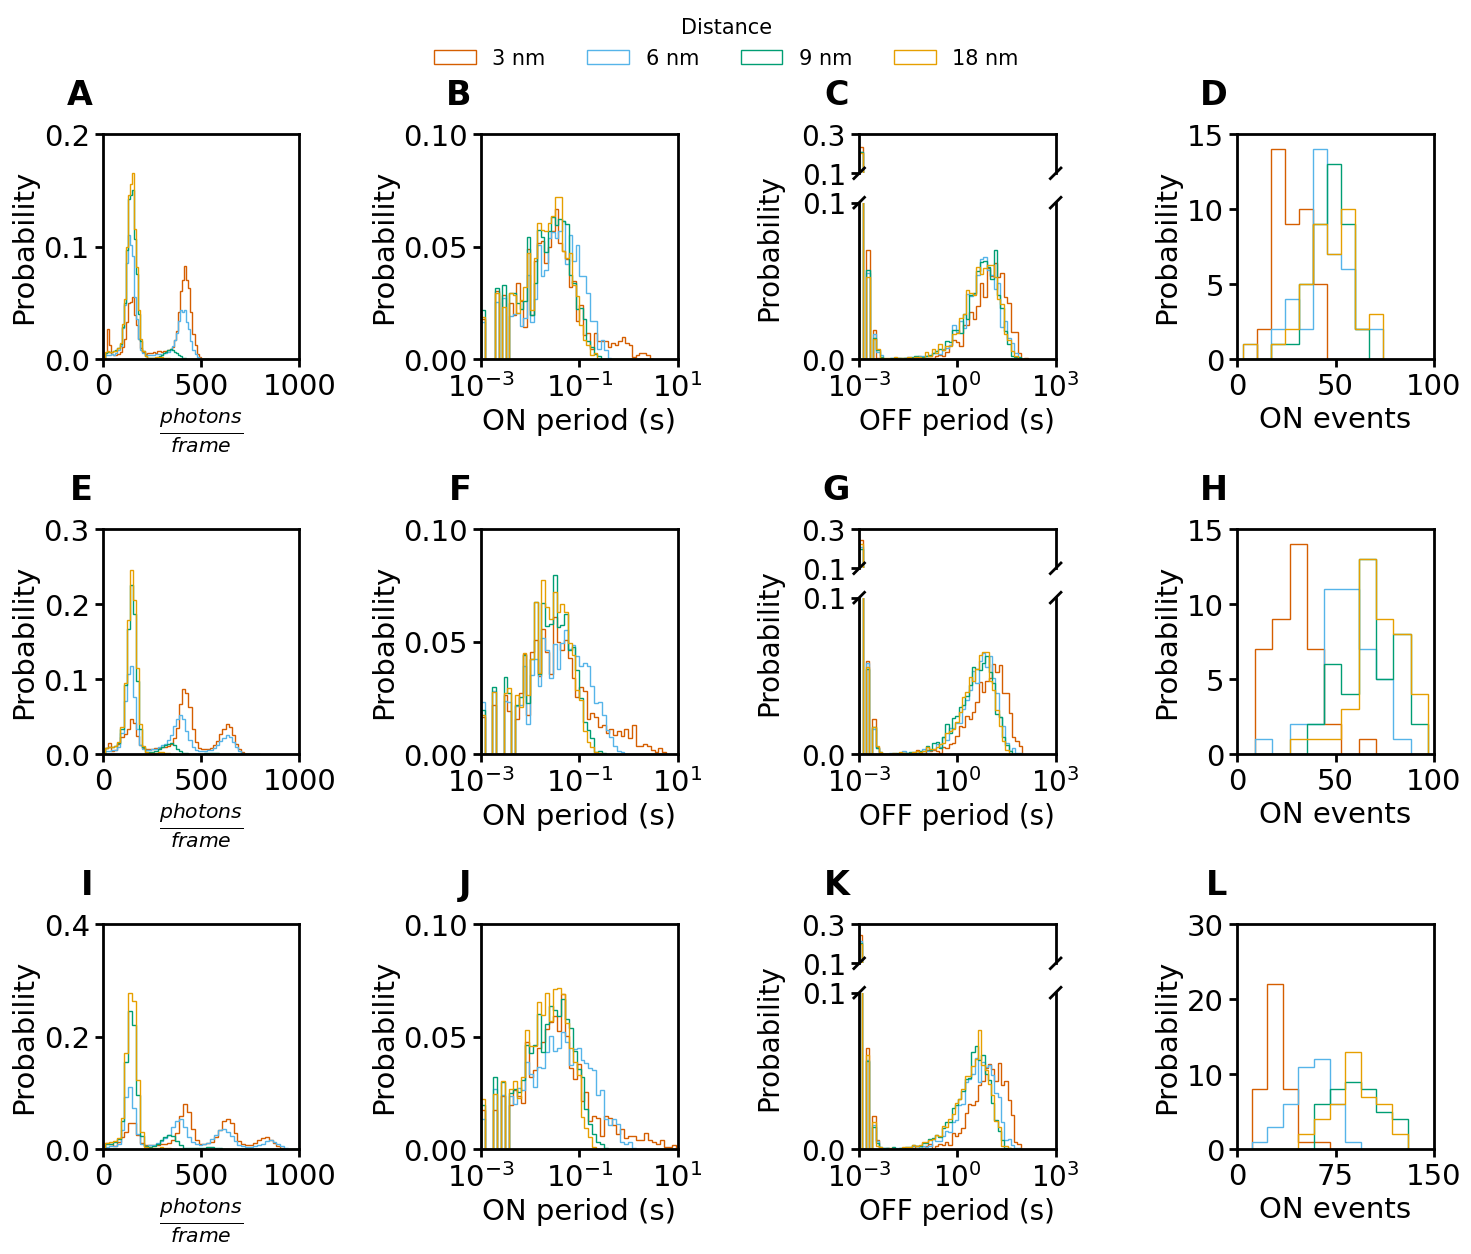

In [24]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 4)
fig = plt.figure(figsize=(15, 12))

labels1 = ["3 nm", "6 nm", "9 nm", "18 nm"]
legendtitle1 = "Distance"
ax1 = fig.add_subplot(gs[0, 0])
fi.universal_figure(
    type_="hist",
    data=list(reversed(intensities_2f_all)),
    axes=ax1,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    alpha=1,
    color=list(reversed(colors)),
    bins=50,
    weights=list(reversed(weights_intensities_2f)),
    ylabel="Probability",
    xlabel=r"$\frac{photons}{frame}$",
    ylim=[0, 0.2],
    xlim=[0, 1000],
)
ax2 = fig.add_subplot(gs[0, 1])
fi.universal_figure(
    type_="hist",
    data=list(reversed(ON_periods_2f_all)),
    axes=ax2,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    alpha=1,
    color=list(reversed(colors)),
    bins=log_bins_ON_2f,
    weights=list(reversed(weights_ON_2f)),
    xscale="log",
    ylabel="Probability",
    xlabel="ON period (s)",
    ylim=[0, 0.1],
    xlim=[1e-3, 1e1],
)

bax3 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.3)),
    subplot_spec=gs[0, 2],
    despine=False,
    d=0.005,
    hspace=0.3,
    height_ratios=(1, 4),
)
bax3.hist(
    list(reversed(OFF_periods_2f_all)),
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    color=list(reversed(colors)),
    alpha=1,
    bins=log_bins_OFF_2f,
    weights=list(reversed(weights_OFF_2f)),
)
bax3.set_xscale("log")
bax3.set_ylabel("Probability", fontsize=20, labelpad=55)
bax3.set_xlabel("OFF period (s)", fontsize=20, labelpad=35)
bax3.tick_params(labelsize=20, width=2, length=6)
bax3.set_xlim([1e-3, 1e3])
bax3.set_xticks([1e-3, 1e0, 1e3])
bax3.axs[0].set_yticks([0.1, 0.3])
bax3.axs[1].set_yticks([0, 0.1])

ax4 = fig.add_subplot(gs[0, 3])
fi.universal_figure(
    type_="hist",
    data=list(reversed(number_ON_periods_2f_all)),
    axes=ax4,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    alpha=1,
    color=list(reversed(colors)),
    ylabel="Probability",
    xlabel="ON events",
    xlim=[0, 100],
    ylim=[0, 15],
)

ax5 = fig.add_subplot(gs[1, 0])
fi.universal_figure(
    type_="hist",
    data=list(reversed(intensities_3f_all)),
    axes=ax5,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    alpha=1,
    color=list(reversed(colors)),
    bins=50,
    weights=list(reversed(weights_intensities_3f)),
    ylabel="Probability",
    xlabel=r"$\frac{photons}{frame}$",
    ylim=[0, 0.3],
    xlim=[0, 1000],
)
ax6 = fig.add_subplot(gs[1, 1])
fi.universal_figure(
    type_="hist",
    data=list(reversed(ON_periods_3f_all)),
    axes=ax6,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    alpha=1,
    color=list(reversed(colors)),
    bins=log_bins_ON_3f,
    weights=list(reversed(weights_ON_3f)),
    xscale="log",
    ylabel="Probability",
    xlabel="ON period (s)",
    ylim=[0, 0.1],
    xlim=[1e-3, 1e1],
)

bax7 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.3)),
    subplot_spec=gs[1, 2],
    despine=False,
    d=0.005,
    hspace=0.3,
    height_ratios=(1, 4),
)
bax7.hist(
    list(reversed(OFF_periods_3f_all)),
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    color=list(reversed(colors)),
    alpha=1,
    bins=log_bins_OFF_3f,
    weights=list(reversed(weights_OFF_3f)),
)
bax7.set_xscale("log")
bax7.set_ylabel("Probability", fontsize=20, labelpad=55)
bax7.set_xlabel("OFF period (s)", fontsize=20, labelpad=35)
bax7.tick_params(labelsize=20, width=2, length=6)
bax7.set_xlim([1e-3, 1e3])
bax7.set_xticks([1e-3, 1e0, 1e3])
bax7.axs[0].set_yticks([0.1, 0.3])
bax7.axs[1].set_yticks([0, 0.1])

ax8 = fig.add_subplot(gs[1, 3])
fi.universal_figure(
    type_="hist",
    data=list(reversed(number_ON_periods_3f_all)),
    axes=ax8,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    alpha=1,
    color=list(reversed(colors)),
    ylabel="Probability",
    xlabel="ON events",
    xlim=[0, 100],
    ylim=[0, 15],
)


ax9 = fig.add_subplot(gs[2, 0])
fi.universal_figure(
    type_="hist",
    data=list(reversed(intensities_4f_all)),
    axes=ax9,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    alpha=1,
    color=list(reversed(colors)),
    bins=50,
    weights=list(reversed(weights_intensities_4f)),
    ylabel="Probability",
    xlabel=r"$\frac{photons}{frame}$",
    ylim=[0, 0.4],
    xlim=[0, 1000],
)
ax10 = fig.add_subplot(gs[2, 1])
fi.universal_figure(
    type_="hist",
    data=list(reversed(ON_periods_4f_all)),
    axes=ax10,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    alpha=1,
    color=list(reversed(colors)),
    bins=log_bins_ON_4f,
    weights=list(reversed(weights_ON_4f)),
    xscale="log",
    ylabel="Probability",
    xlabel="ON period (s)",
    ylim=[0, 0.1],
    xlim=[1e-3, 1e1],
)

bax11 = brokenaxes(
    ylims=((0, 0.1), (0.1, 0.3)),
    subplot_spec=gs[2, 2],
    despine=False,
    d=0.005,
    hspace=0.3,
    height_ratios=(1, 4),
)
bax11.hist(
    list(reversed(OFF_periods_4f_all)),
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    color=list(reversed(colors)),
    alpha=1,
    bins=log_bins_OFF_4f,
    weights=list(reversed(weights_OFF_4f)),
)
bax11.set_xscale("log")
bax11.set_ylabel("Probability", fontsize=20, labelpad=55)
bax11.set_xlabel("OFF period (s)", fontsize=20, labelpad=35)
bax11.tick_params(labelsize=20, width=2, length=6)
bax11.set_xlim([1e-3, 1e3])
bax11.set_xticks([1e-3, 1e0, 1e3])
bax11.axs[0].set_yticks([0.1, 0.3])
bax11.axs[1].set_yticks([0, 0.1])

ax12 = fig.add_subplot(gs[2, 3])
fi.universal_figure(
    type_="hist",
    data=list(reversed(number_ON_periods_4f_all)),
    axes=ax12,
    density=False,
    histtype="step",
    label=list(reversed(labels1)),
    alpha=1,
    color=list(reversed(colors)),
    ylabel="Probability",
    xlabel="ON events",
    xlim=[0, 150],
    ylim=[0, 30],
    xticks=[0, 75, 150],
)


letters = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L"]
axes = fig.get_axes()
j = 0
for i, axis in enumerate(axes):
    if i in [2, 3, 8, 9, 14, 15]:
        continue
    offset = -0.05
    axis.text(
        offset,
        1.1,
        letters[j],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
    j += 1

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.05),
    frameon=False,
    title="Distance",
    title_fontsize=15,
    fontsize=15,
)
fig.tight_layout()
for handle1, handle2, handle3 in zip(
    bax3.diag_handles, bax7.diag_handles, bax11.diag_handles
):
    handle1.remove()
    handle2.remove()
    handle3.remove()
bax3.draw_diags()
bax7.draw_diags()
bax11.draw_diags()
fig.savefig(
    saving_to + r"\multi_f_PFA_add_1.png", dpi=300, bbox_inches="tight", pad_inches=0.1
)

### <a id='toc1_2_3_'></a>[Figure 2](#toc0_)

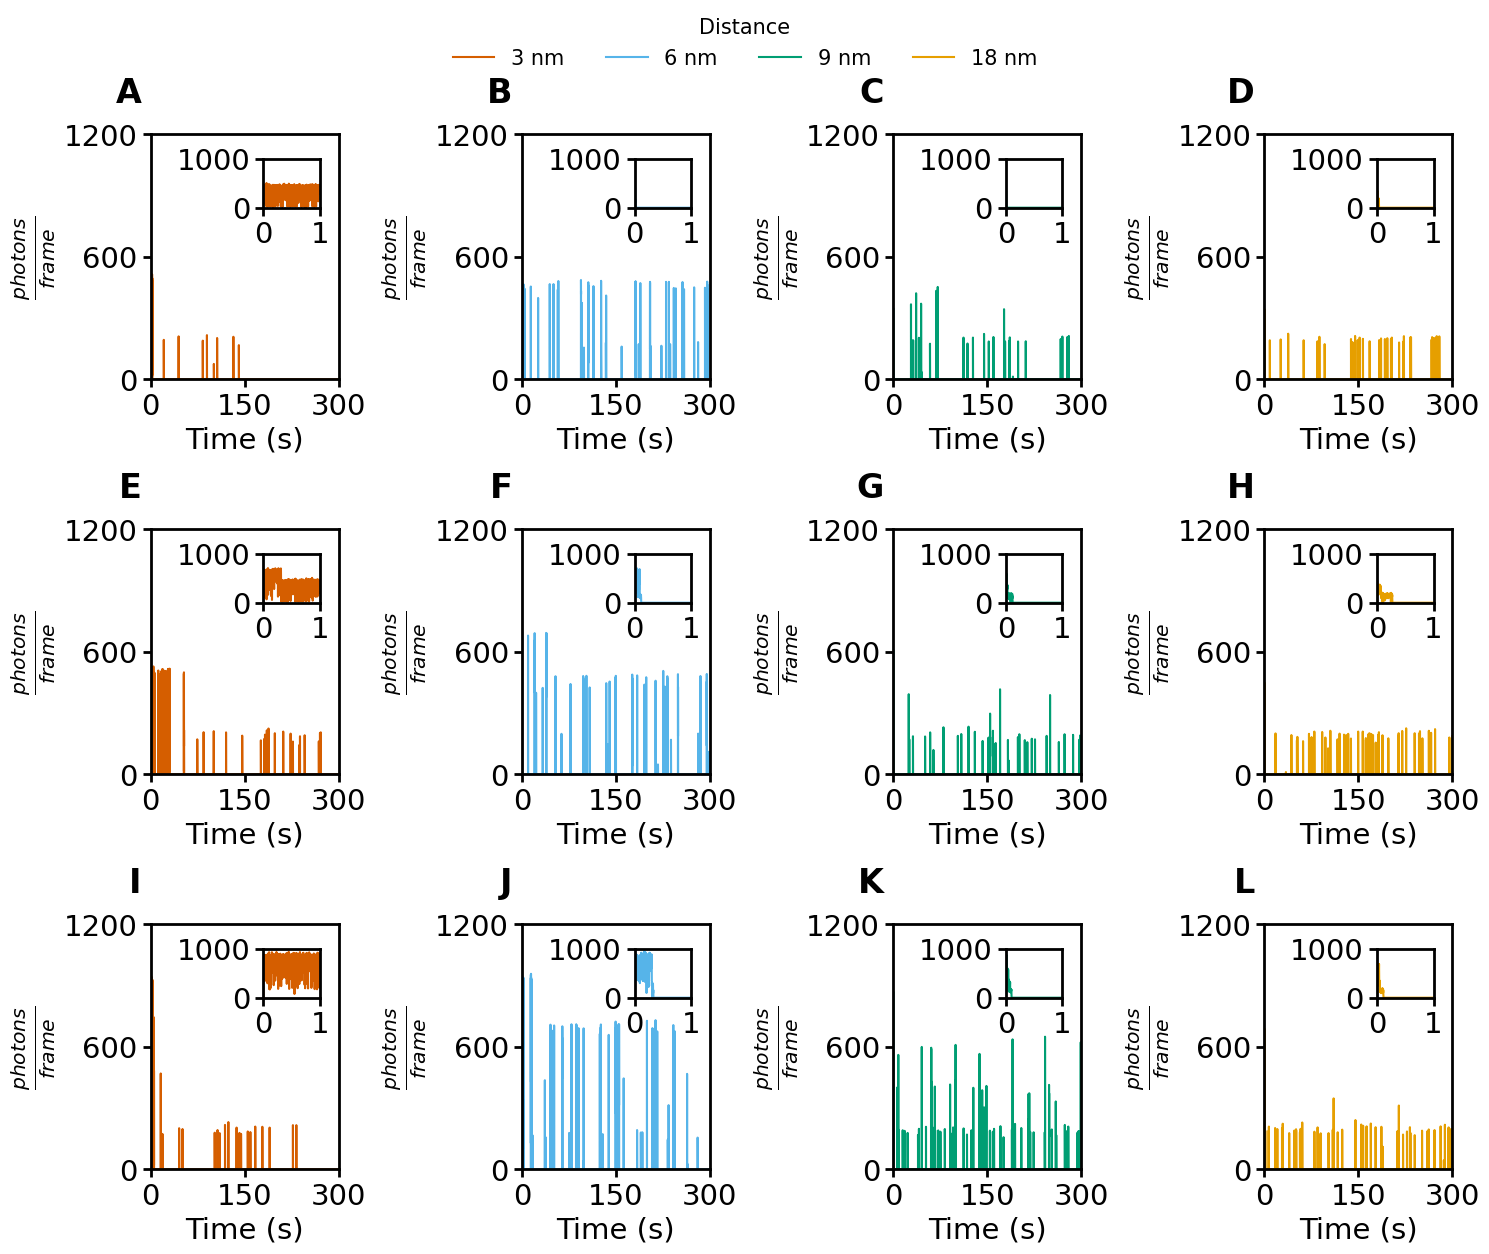

In [9]:
def add_inset(ax, emis, color):
    inset = ax.inset_axes([0.6, 0.7, 0.3, 0.2], xlim=(0, 1), ylim=(0, 1000))
    emis.plot_time_series(axes=inset, color=color)
    inset.set_xlabel("")
    inset.set_ylabel("")


red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 4)
fig = plt.figure(figsize=(15, 12))

labels1 = ["3 nm", "6 nm", "9 nm", "18 nm"]
legendtitle1 = "Distance"
handles, labels = [], []
for i, emis in enumerate(emis_collection_2f):
    ax = fig.add_subplot(gs[0, i])
    emis.plot_time_series(
        axes=ax,
        color=colors[i],
        label=labels1[i],
        ylim=[0, 1200],
        yticks=[0, 600, 1200],
        xticks=[0, 150, 300],
        xlim=[0, 300],
    )
    handle, label = ax.get_legend_handles_labels()
    handles.append(handle[0])
    labels.append(label[0])
    add_inset(ax, emis, colors[i])

for i, emis in enumerate(emis_collection_3f):
    ax = fig.add_subplot(gs[1, i])
    emis.plot_time_series(
        axes=ax,
        color=colors[i],
        ylim=[0, 1200],
        yticks=[0, 600, 1200],
        xticks=[0, 150, 300],
        xlim=[0, 300],
    )
    add_inset(ax, emis, colors[i])
for i, emis in enumerate(emis_collection_4f):
    ax = fig.add_subplot(gs[2, i])
    emis.plot_time_series(
        axes=ax,
        color=colors[i],
        ylim=[0, 1200],
        yticks=[0, 600, 1200],
        xticks=[0, 150, 300],
        xlim=[0, 300],
    )
    add_inset(ax, emis, colors[i])


axes = fig.get_axes()
for axis, letter in zip(
    axes, ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L"]
):
    offset = -0.05
    axis.text(
        offset,
        1.1,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.05),
    frameon=False,
    title="Distance",
    title_fontsize=15,
    fontsize=15,
)
fig.tight_layout()
fig.savefig(
    saving_to + r"\multi_f_PFA_add_2.png", dpi=300, bbox_inches="tight", pad_inches=0.1
)